[Home](../../README.md)

### Model Evaluation

This is a demonstration of evaluating a model.

#### Step 1

Load the required dependencies.


In [1]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')
from sklearn.linear_model import LinearRegression
import pickle

####  Step 2

Load the model for testing

In [2]:
filename = 'my_saved_model_v1.sav'
model_A = pickle.load(open(filename, 'rb'))


(Optional) Load a second model if you want to do comparative testing

In [3]:
filename = 'my_saved_model_v1.sav'
model_B = pickle.load(open(filename, 'rb'))

####  Step 3
Open and parse the test data CSV file and store the data as variable array data objects.

In [4]:
x_col = 'BMI'
testing_data = pd.read_csv('2.4.1.testing_data.csv')
x_test = np.array(testing_data[x_col]).reshape(-1,1)
y_test = np.array(testing_data['Target'])

#### Step 5

Plot the test data features, targets and linear regression model to visually evaluate the model.

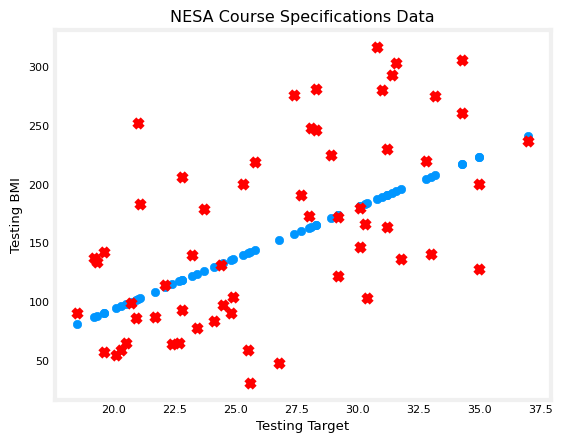

In [5]:
y_pred = model_A.predict(x_test)
plt.scatter(x_test, y_pred)
plt.scatter(x_test, y_test, marker='x', c='r')
plt.title("NESA Course Specifications Data")
plt.ylabel(f'Testing {x_col}')
plt.xlabel(f'Testing Target')
plt.show()

#### Step 6

Use the 'score' method of the `LinearRegression` class to return a score based evaluation of the models accuracy or performance.

In [6]:
test_score = model_A.score(x_test, y_test)
print(f'Training data score: {test_score}')

Training data score: 0.3282561770798472


#### Step 7

Manually calculate and evaluate the 'loss' and 'cost' of the model using the test data.

In [7]:
table = pd.DataFrame({
    testing_data.columns[0]: x_test.flatten(),  # Flatten x for easy display
    testing_data.columns[1]: y_test,
    'Predicted result':model_A.predict(x_test),
    'Loss' : abs(model_A.predict(x_test).round(2) - y_test)**2
})
print(table)
cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()

print(f"The cost or average loss of this model is {cost}")

     DoB    DoT  Predicted result        Loss
0   27.4  276.0        157.886858  13949.9721
1   26.8   48.0        152.704903  10962.0900
2   30.4  103.0        183.796634   6528.6400
3   19.6   57.0         90.521441   1123.5904
4   31.0  280.0        188.978589   8284.6404
5   24.4  131.0        131.977082      0.9604
6   28.3  246.0        165.659791   6454.5156
7   32.8  220.0        204.524455    239.6304
8   22.7   65.0        117.294876   2734.2441
9   31.8  136.0        195.887863   3586.8121
10  22.8  206.0        118.158535   7715.8656
11  23.2  140.0        121.613172    338.1921
12  28.3  281.0        165.659791  13303.3156
13  22.1  114.0        112.112920      3.5721
14  30.1  180.0        181.205656      1.4641
15  25.3  200.0        139.750015   3630.0625
16  18.5   90.0         81.021189     80.6404
17  25.5   59.0        141.477333   6802.9504
18  20.3   59.0         96.567055   1411.5049
19  25.6   31.0        142.340992  12396.5956
20  23.4   78.0        123.340490 

You may want to do some manual predictions to understand your model.

In [8]:
print(model_A.predict([[0.1]]))
print(model_A.predict([[1]]))

[-77.89210285]
[-70.11917008]


#### Step 8

Evaluate the X axis intercept and gradient or coefficient of your model by using the getter methods to return the intercept and coefficient from my_model() object.

In [9]:
print(f'X Axis intercept: {model_A.intercept_}')
print(f'Coefficient: {model_A.coef_}')

X Axis intercept: -78.75576204938278
Coefficient: [8.63659197]


#### Step 9. Multiple Variable Linear Regression

You should be able to understand the code snippets with less guidelines.

In [10]:
filename = 'my_saved_model_v2.sav'
model_C = pickle.load(open(filename, 'rb'))

In [11]:
mx_col = ['BMI','BP','FDR']
testing_data = pd.read_csv('2.4.1.testing_data.csv')
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data['Target'])

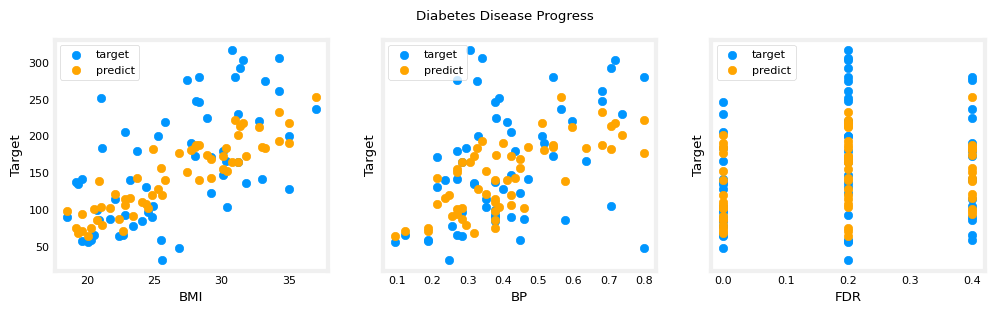

In [12]:
my_pred = model_C.predict(mx_test)

# plot predictions and targets vs original features    
fig,ax=plt.subplots(1,len(mx_col),figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(mx_test[:,i],my_test, label = 'target')
    ax[i].set_xlabel(mx_col[i])
    ax[i].scatter(mx_test[:,i],my_pred,color="orange", label = 'predict')
    ax[i].set_ylabel("Target"); ax[i].legend();
fig.suptitle("Diabetes Disease Progress")
plt.show()

In [13]:
test_score = model_C.score(mx_test, my_test)
print(f'Training data score: {test_score}')

Training data score: 0.34944599787619113


In [14]:
print(model_C.predict([[0.1,0.1,0.1]]))
print(model_C.predict([[1,0.5,1]]))

[-87.74264463]
[29.53796749]


In [15]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['Target'] = my_test
data['Predicted result'] = model_C.predict(mx_test)
data['Loss'] = abs(model_C.predict(mx_test).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

The cost or average loss of this model is 1997.4272830508478
     BMI        BP  FDR  Target  Predicted result        Loss
0   27.4  0.270588  0.4   276.0        150.376740  15780.3844
1   26.8  0.800000  0.0    48.0        177.271806  16710.7329
2   30.4  0.352941  0.0   103.0        152.377931   2438.3844
3   19.6  0.188235  0.2    57.0         70.229080    175.0329
4   31.0  0.800000  0.2   280.0        222.077902   3354.7264
5   24.4  0.211765  0.2   131.0        107.535021    550.3716
6   28.3  0.376471  0.0   246.0        139.904957  11257.2100
7   32.8  0.596118  0.2   220.0        211.866368     66.0969
8   22.7  0.121529  0.0    65.0         70.497968     30.2500
9   31.8  0.317647  0.2   136.0        172.968191   1366.7809
10  22.8  0.423529  0.0   206.0        105.580374  10084.1764
11  23.2  0.235294  0.4   140.0        116.060835    573.1236
12  28.3  0.541176  0.4   281.0        187.656645   8712.3556
13  22.1  0.352941  0.4   114.0        121.510720     56.4001
14  30.1 

In [16]:
print(f'X Axis intercept: {model_C.intercept_}')
print(f'Coefficient: {model_C.coef_}')

X Axis intercept: -107.0948267253421
Coefficient: [  7.21433546 113.77805341  72.52943205]


#### Step 10. Polynomial Linear Regression

You should be able to understand the code snippets with less guidelines.

In [17]:
model_filename = 'my_saved_model_v3.sav'
poly_filename = 'my_saved_poly_v3.pkl'

model_D = pickle.load(open(model_filename, 'rb'))
poly = pickle.load(open(poly_filename, 'rb'))

In [18]:
mx_col = ['BMI']
testing_data = pd.read_csv('2.4.1.testing_data.csv')
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data['Target'])

In [19]:
poly_features = poly.fit_transform(mx_test)

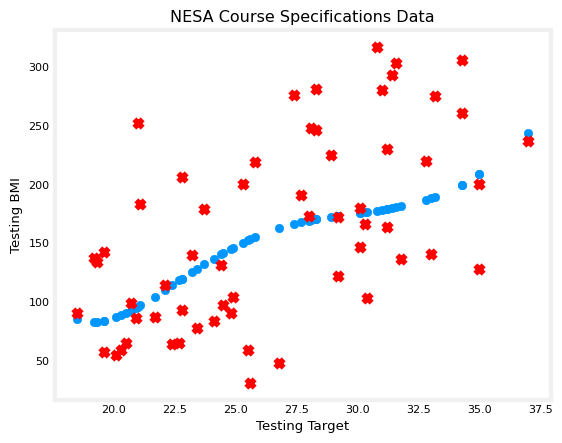

In [20]:
y_pred = model_D.predict(poly_features)

plt.scatter(x_test, y_pred)
plt.scatter(x_test, y_test, marker='x', c='r')
plt.title("NESA Course Specifications Data")
plt.ylabel(f'Testing {x_col}')
plt.xlabel(f'Testing Target')
plt.show()

In [21]:
test_score = model_D.score(poly_features, my_test)
print(f'Training data score: {test_score}')

Training data score: 0.28410139929718403


In [22]:
new_poly_feature = poly.fit_transform([[0.1]])
print(model_D.predict(new_poly_feature))

[12887.91877398]


In [23]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['Target'] = my_test
data['Predicted result'] = model_D.predict(poly_features)
data['Loss'] = abs(model_D.predict(poly_features).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

The cost or average loss of this model is 2198.040612711864
     BMI  Target  Predicted result        Loss
0   27.4   276.0        166.020845  12095.6004
1   26.8    48.0        162.496639  13110.2500
2   30.4   103.0        176.408343   5389.0281
3   19.6    57.0         83.908918    724.1481
4   31.0   280.0        178.216229  10359.1684
5   24.4   131.0        140.414143     88.5481
6   28.3   246.0        170.081972   5763.8464
7   32.8   220.0        186.589510   1116.2281
8   22.7    65.0        118.115208   2821.7344
9   31.8   136.0        181.223130   2044.8484
10  22.8   206.0        119.504214   7482.2500
11  23.2   140.0        125.010206    224.7001
12  28.3   281.0        170.081972  12303.2464
13  22.1   114.0        109.791427     17.7241
14  30.1   180.0        175.577297     19.5364
15  25.3   200.0        150.224517   2478.0484
16  18.5    90.0         84.941388     25.6036
17  25.5    59.0        152.160380   8678.7856
18  20.3    59.0         88.456674    867.8916


#### Step 11

When your model is ready for operations, move it to the [3.Operations\3.1.Deploy_Model](\3.Operations\3.1.Deploy_Model) folder.